<h1>Table of Contents (Previously Part 2) <span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Expression-Quality-Control-(Part-2)" data-toc-modified-id="Expression-Quality-Control-(Part-2)-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Expression Quality Control (Part 2)</a></span><ul class="toc-item"><li><span><a href="#Setup" data-toc-modified-id="Setup-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Setup</a></span><ul class="toc-item"><li><span><a href="#Inputs" data-toc-modified-id="Inputs-1.1.1"><span class="toc-item-num">1.1.1&nbsp;&nbsp;</span>Inputs</a></span></li><li><span><a href="#Load-expression-data" data-toc-modified-id="Load-expression-data-1.1.2"><span class="toc-item-num">1.1.2&nbsp;&nbsp;</span>Load expression data</a></span></li><li><span><a href="#Load-metadata" data-toc-modified-id="Load-metadata-1.1.3"><span class="toc-item-num">1.1.3&nbsp;&nbsp;</span>Load metadata</a></span></li></ul></li><li><span><a href="#Remove-samples-due-to-poor-metadata" data-toc-modified-id="Remove-samples-due-to-poor-metadata-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Remove samples due to poor metadata</a></span><ul class="toc-item"><li><span><a href="#Check-curation" data-toc-modified-id="Check-curation-1.2.1"><span class="toc-item-num">1.2.1&nbsp;&nbsp;</span>Check curation</a></span></li><li><span><a href="#Remove-samples-with-only-one-replicate" data-toc-modified-id="Remove-samples-with-only-one-replicate-1.2.2"><span class="toc-item-num">1.2.2&nbsp;&nbsp;</span>Remove samples with only one replicate</a></span></li><li><span><a href="#Save-this-information-to-the-full-metadata-dataframe" data-toc-modified-id="Save-this-information-to-the-full-metadata-dataframe-1.2.3"><span class="toc-item-num">1.2.3&nbsp;&nbsp;</span>Save this information to the full metadata dataframe</a></span></li></ul></li><li><span><a href="#Check-correlations-between-replicates" data-toc-modified-id="Check-correlations-between-replicates-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Check correlations between replicates</a></span><ul class="toc-item"><li><span><a href="#Remove-failed-data-from-log_tpm-files" data-toc-modified-id="Remove-failed-data-from-log_tpm-files-1.3.1"><span class="toc-item-num">1.3.1&nbsp;&nbsp;</span>Remove failed data from log_tpm files</a></span></li><li><span><a href="#Compute-Pearson-R-Score" data-toc-modified-id="Compute-Pearson-R-Score-1.3.2"><span class="toc-item-num">1.3.2&nbsp;&nbsp;</span>Compute Pearson R Score</a></span></li></ul></li><li><span><a href="#Check-that-reference-conditions-still-exist" data-toc-modified-id="Check-that-reference-conditions-still-exist-1.4"><span class="toc-item-num">1.4&nbsp;&nbsp;</span>Check that reference conditions still exist</a></span></li><li><span><a href="#Normalize-dataset-to-reference-conditions" data-toc-modified-id="Normalize-dataset-to-reference-conditions-1.5"><span class="toc-item-num">1.5&nbsp;&nbsp;</span>Normalize dataset to reference conditions</a></span></li><li><span><a href="#Save-final-datasets" data-toc-modified-id="Save-final-datasets-1.6"><span class="toc-item-num">1.6&nbsp;&nbsp;</span>Save final datasets</a></span></li></ul></li></ul></div>

# Expression Quality Control (Part 2)

This is a template notebook for performing the final quality control on your organism's expression data. This requires a curated metadata sheet.

## Setup 

In [ ]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns
sns.set_style('ticks')

from os import path
from scipy import stats
from tqdm.notebook import tqdm

import re

### Inputs

In [3]:
logTPM_file = path.join('..','ctherm_nf','nf_results','log_tpm.csv') # Enter log-TPM filename here
all_metadata_file = path.join('.', 'output_qc', 'interim', 'metadata_qc_part1_all.tsv') # Enter filename for full metadata QC file
metadata_file = path.join('.', 'output_qc', 'interim', 'sra_growth_metadata_ctherm_curated_p2.tsv') # Enter filename for metadata QC file with only passing datasets + manual curation

### Load expression data

In [4]:
DF_log_tpm = pd.read_csv(logTPM_file,index_col=0).fillna(0)
print('Number of genes:',DF_log_tpm.shape[0])
print('Number of samples:',DF_log_tpm.shape[1])
DF_log_tpm.head()

Number of genes: 2911
Number of samples: 325


,SRX1014220,SRX1014221,SRX1014223,SRX1014225,SRX1014226,SRX1014227,SRX1014228,SRX1014230,SRX1014231,SRX1014232,...,SRX7195454,SRX7195455,SRX7195456,SRX7195457,SRX7195458,SRX7195459,SRX7195460,SRX7195461,SRX7195462,SRX974531
Geneid,,,,,,,,,,,,,,,,,,,,,
Clo1313_0001,7.551777,7.731136,7.771201,6.375955,6.322270,6.423123,7.645399,7.527894,8.227711,7.499026,...,8.263745,8.270868,8.044656,8.326490,8.740112,7.095610,8.263641,7.529287,7.210684,8.899166
Clo1313_0002,7.752602,8.004967,7.964131,5.543052,5.438840,5.654808,7.980810,7.782816,8.124167,7.780386,...,7.997551,8.130777,7.552272,8.061540,8.474935,6.431477,7.917540,7.321251,7.091575,7.551028
Clo1313_0003,8.887143,9.171801,9.355592,6.211352,6.098789,6.254218,9.203208,8.993602,9.383468,8.842177,...,7.385063,7.535819,6.724409,7.487562,7.825918,5.634515,7.399767,6.911327,6.438412,7.227122
Clo1313_0004,7.043892,7.110695,7.293854,4.387811,4.406844,4.493506,7.074095,6.846041,7.339102,7.101972,...,6.473204,6.670690,6.217058,6.608325,6.879623,5.272492,6.553680,5.919809,5.869959,6.986597
Clo1313_0005,7.979446,8.252763,8.182836,7.266938,7.243592,7.191651,8.453759,8.452603,8.736243,8.297923,...,7.705822,7.770806,8.178356,7.752933,7.833385,8.122050,7.828161,7.648701,8.894601,8.436938


### Load metadata

In [5]:
DF_metadata = pd.read_csv(metadata_file,index_col=0,sep='\t')
print('Number of samples with curated metadata:',DF_metadata.shape[0])
DF_metadata.head()

Number of samples with curated metadata: 236


,Run,ReleaseDate,LoadDate,spots,bases,spots_with_mates,avgLength,size_MB,AssemblyName,download_path,...,Unnamed: 108,Unnamed: 109,strain_description,base_media,carbon_source,OD,growth_phase,notes,culture_type,condtion
SRA_Accession,,,,,,,,,,,,,,,,,,,,,
SRX1014220,SRR2002673,2015-11-02 10:20:11,2015-04-29 18:42:39,36341975,1817098750,0,50,726,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,mid-log,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_midlog
SRX1014221,SRR2002674,2015-11-02 10:20:11,2015-04-29 18:42:02,23864175,1193208750,0,50,451,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,mid-log,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_midlog
SRX1014223,SRR2002676,2015-11-02 10:20:11,2015-04-29 18:42:24,30611161,1530558050,0,50,612,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,late-log,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_latelog
SRX1014225,SRR2002678,2015-11-02 10:20:11,2015-04-29 18:41:57,29139446,1456972300,0,50,590,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,stationary,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_sta
SRX1014226,SRR2002679,2015-11-02 10:20:11,2015-04-29 18:42:42,26904972,1345248600,0,50,540,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,stationary,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_sta


In [6]:
DF_metadata_all = pd.read_csv(all_metadata_file,index_col=0,sep='\t')

## Remove samples due to poor metadata

After curation, some samples either did not have enough replicates or metadata to warrant inclusion in this database. Add a `skip` column to the metadata to exclude these samples.

In [7]:
DF_metadata_passed_step4 = DF_metadata[~DF_metadata['skip'].fillna(False)].copy() #change this here as skip is a method in pandas dataframe now
print('New number of samples with curated metadata:',DF_metadata_passed_step4.shape[0])
DF_metadata_passed_step4.head()

New number of samples with curated metadata: 236


,Run,ReleaseDate,LoadDate,spots,bases,spots_with_mates,avgLength,size_MB,AssemblyName,download_path,...,Unnamed: 108,Unnamed: 109,strain_description,base_media,carbon_source,OD,growth_phase,notes,culture_type,condtion
SRA_Accession,,,,,,,,,,,,,,,,,,,,,
SRX1014220,SRR2002673,2015-11-02 10:20:11,2015-04-29 18:42:39,36341975,1817098750,0,50,726,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,mid-log,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_midlog
SRX1014221,SRR2002674,2015-11-02 10:20:11,2015-04-29 18:42:02,23864175,1193208750,0,50,451,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,mid-log,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_midlog
SRX1014223,SRR2002676,2015-11-02 10:20:11,2015-04-29 18:42:24,30611161,1530558050,0,50,612,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,late-log,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_latelog
SRX1014225,SRR2002678,2015-11-02 10:20:11,2015-04-29 18:41:57,29139446,1456972300,0,50,590,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,stationary,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_sta
SRX1014226,SRR2002679,2015-11-02 10:20:11,2015-04-29 18:42:42,26904972,1345248600,0,50,540,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,stationary,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_sta


### Check curation
Since manual curation is error-prone, we want to make sure that all samples have labels for their project and condition. In addition, there should only be one reference condition in each project, and it should be in the project itself.

Any samples that fail these checks will be printed below.

In [8]:
assert(DF_metadata_passed_step4.project.notnull().all())
assert(DF_metadata_passed_step4.condition.notnull().all())

for name,group in DF_metadata_passed_step4.groupby('project'):
    ref_cond = group.reference_condition.unique()
    
    # Ensure that there is only one reference condition per project
    if not len(ref_cond) == 1:
        print('Multiple reference conditions for:, name')
    
    # Ensure the reference condition is in fact in the project
    ref_cond = ref_cond[0]
    if not ref_cond in group.condition.tolist():
        print('Reference condition not in project:', name)

Next, make a new column called ``full_name`` that gives every experimental condition a unique, human-readable identifier.

In [11]:
DF_metadata_passed_step4['full_name'] = DF_metadata_passed_step4['project'].str.cat(DF_metadata_passed_step4['condition'],sep=':')

### Remove samples with only one replicate

First, find sample names that have at least two replicates.

In [12]:
counts = DF_metadata_passed_step4.full_name.value_counts()
keep_samples = counts[counts >= 2].index
print(keep_samples[:5])

Index(['eh_chemostat:wt_clim', 'eh_chemostat:wt_nlim',
       'eh_chemostat:evo_ph_aux_del_hpt_del_spo0A_del_ldh_del_pta_ins_pgapD-cat-hpt_clim',
       'cell_stressor:60T_mtc', 'cell_stressor:50T_mtc'],
      dtype='object', name='full_name')


Only keep these samples

In [13]:
DF_metadata_passed_step4 = DF_metadata_passed_step4[DF_metadata_passed_step4.full_name.isin(keep_samples)]
print('New number of samples with curated metadata:',DF_metadata_passed_step4.shape[0])
DF_metadata_passed_step4.head()

New number of samples with curated metadata: 229


,Run,ReleaseDate,LoadDate,spots,bases,spots_with_mates,avgLength,size_MB,AssemblyName,download_path,...,Unnamed: 109,strain_description,base_media,carbon_source,OD,growth_phase,notes,culture_type,condtion,full_name
SRA_Accession,,,,,,,,,,,,,,,,,,,,,
SRX1014220,SRR2002673,2015-11-02 10:20:11,2015-04-29 18:42:39,36341975,1817098750,0,50,726,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,mid-log,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_midlog,lacI:del_hpt_del_Clo1313_0089_midlog
SRX1014221,SRR2002674,2015-11-02 10:20:11,2015-04-29 18:42:02,23864175,1193208750,0,50,451,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,mid-log,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_midlog,lacI:del_hpt_del_Clo1313_0089_midlog
SRX1014225,SRR2002678,2015-11-02 10:20:11,2015-04-29 18:41:57,29139446,1456972300,0,50,590,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,stationary,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_sta,lacI:del_hpt_del_Clo1313_0089_sta
SRX1014226,SRR2002679,2015-11-02 10:20:11,2015-04-29 18:42:42,26904972,1345248600,0,50,540,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,stationary,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_sta,lacI:del_hpt_del_Clo1313_0089_sta
SRX1014227,SRR2002680,2015-11-02 10:20:11,2015-04-29 18:42:33,27853760,1392688000,0,50,526,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,stationary,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_sta,lacI:del_hpt_del_Clo1313_0089_sta


### Save this information to the full metadata dataframe

In [14]:
DF_metadata_all['passed_curation'] = DF_metadata_all.index.isin(DF_metadata_passed_step4.index)

## Check correlations between replicates

### Remove failed data from log_tpm files

In [15]:
DF_log_tpm = DF_log_tpm[DF_metadata_passed_step4.index]

### Compute Pearson R Score

Biological replicates should have a Pearson R correlation above 0.95. For samples with more than 2 replicates, the replicates must have R >= 0.95 with at least one other replicate or it will be dropped. The correlation threshold can be changed below:

In [16]:
rcutoff = 0.95

The following code computes correlations between all samples and collects correlations between replicates and non-replicates.

In [17]:
rep_corrs = {}
rand_corrs = {}

num_comparisons = len(DF_metadata_passed_step4)*(len(DF_metadata_passed_step4)-1)/2

for exp1,exp2 in tqdm(itertools.combinations(DF_metadata_passed_step4.index,2),total=num_comparisons):
    if DF_metadata_passed_step4.loc[exp1,'full_name'] == DF_metadata_passed_step4.loc[exp2,'full_name']:
        rep_corrs[(exp1,exp2)] = stats.pearsonr(DF_log_tpm[exp1],DF_log_tpm[exp2])[0]
    else:
        rand_corrs[(exp1,exp2)] = stats.pearsonr(DF_log_tpm[exp1],DF_log_tpm[exp2])[0]

  0%|          | 0/26106.0 [00:00<?, ?it/s]

Correlations can be plotted on a histogram

Median Pearson R between replicates: 0.98
Median Pearson R between non-replicates: 0.86


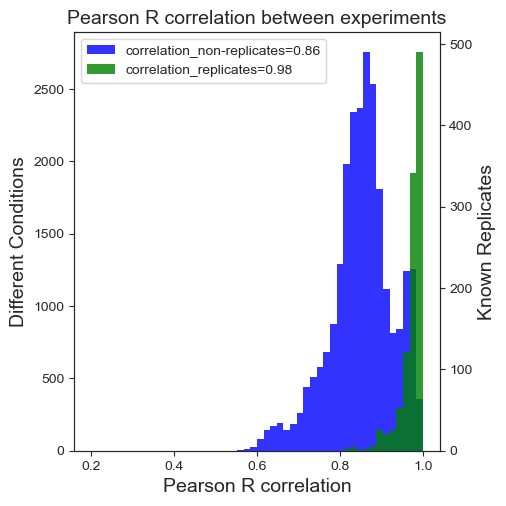

In [18]:
fig,ax = plt.subplots(figsize=(5,5))
ax2 = ax.twinx()

med_corr = np.median([v for k,v in rep_corrs.items()])
print('Median Pearson R between replicates: {:.2f}'.format(med_corr))
ax2.hist(rep_corrs.values(),bins=50,range=(0.2,1),alpha=0.8,color='green',linewidth=0, label=f'correlation_replicates={med_corr:.2f}')
med_corr = np.median([v for k,v in rand_corrs.items()])
print('Median Pearson R between non-replicates: {:.2f}'.format(med_corr))
ax.hist(rand_corrs.values(),bins=50,range=(0.2,1),alpha=0.8,color='blue',linewidth=0, label=f'correlation_non-replicates={med_corr:.2f}')
ax.set_title('Pearson R correlation between experiments',fontsize=14)
ax.set_xlabel('Pearson R correlation',fontsize=14)
ax.set_ylabel('Different Conditions',fontsize=14)
ax2.set_ylabel('Known Replicates',fontsize=14)

# Collect all handles and labels
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

# Combine and create the legend
ax.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout(pad=0.5)

plt.savefig(f'./output_qc/correlation_between_and_within_conditions_ctherm.png', transparent=True, dpi=300)

plt.show()

Remove samples without any high-correlation replicates

In [19]:
dissimilar = []
for idx, grp in DF_metadata_passed_step4.groupby('full_name'):
    ident = np.identity(len(grp))
    corrs = (DF_log_tpm[grp.index].corr() - ident).max()
    dissimilar.extend(corrs[corrs<rcutoff].index)

# Save this information in both the original metadata dataframe and the new metadata dataframe
DF_metadata_all['passed_replicate_correlations'] = ~DF_metadata_all.index.isin(dissimilar)
DF_metadata_passed_step4['passed_replicate_correlations'] = ~DF_metadata_passed_step4.index.isin(dissimilar)

In [20]:
DF_metadata_final = DF_metadata_passed_step4[DF_metadata_passed_step4['passed_replicate_correlations']]
print('# Samples that passed replicate correlations:',len(DF_metadata_final))

# Samples that passed replicate correlations: 226


## Check that reference conditions still exist
If a reference condition was removed due to poor replicate correlations, a new reference condition needs to be defined.

Again, any samples that fail these checks will be printed below.

In [21]:
project_exprs = []
for name,group in DF_metadata_final.groupby('project'):
    
    # Get reference condition
    ref_cond = group.reference_condition.iloc[0]
    
    # Ensure the reference condition is still in the project
    if ref_cond not in group.condition.tolist():
        print('Reference condition missing from:', name)
    
    # Check that each project has at least two conditions (a reference and at least one test condition)
    if len(group.condition.unique()) <= 1:
        print('Only one condition in:', name)

Reference condition missing from: del_gluS
Only one condition in: del_gluS


#### Remove any that are not required

In [22]:
DF_metadata_final = DF_metadata_final.loc[~DF_metadata_final.full_name.str.startswith('del_gluS')]
DF_metadata_final.shape

(223, 112)

In [23]:
len(DF_metadata_final.condition.unique())

51

If necessary, choose a new condition for failed projects and re-run notebook.

## Normalize dataset to reference conditions

In [24]:
DF_log_tpm_final = DF_log_tpm[DF_metadata_final.index]
DF_log_tpm_final.shape

(2911, 223)

In [25]:
project_exprs = []
for name,group in DF_metadata_final.groupby('project'):
    
    # Get reference condition
    ref_cond = group.reference_condition.iloc[0]
    
    # Get reference condition sample ids
    ref_samples = group[group.condition == ref_cond].index
    
    # Get reference condition expression
    ref_expr = DF_log_tpm_final[ref_samples].mean(axis=1)
    
    # Subtract reference expression from project
    project_exprs.append(DF_log_tpm_final[group.index].sub(ref_expr,axis=0))

DF_log_tpm_norm = pd.concat(project_exprs,axis=1)

In [ ]:
DF_log_tpm_norm.head()

,SRX2193597,SRX2193598,SRX2193599,SRX2193600,SRX2193601,SRX2193603,SRX2193604,SRX5085503,SRX5085504,SRX5085505,...,SRX2919066,SRX2919067,SRX2919068,SRX2919069,SRX1427049,SRX1427050,SRX1427051,SRX1427052,SRX1427053,SRX1427055
Geneid,,,,,,,,,,,,,,,,,,,,,
Clo1313_0001,2.187539,2.324120,2.166860,2.119471,-0.615049,0.195897,0.419152,-1.365881,-0.588574,0.320101,...,-0.232536,-1.089016,-0.910419,-1.334298,0.116661,0.104750,-0.221412,0.031879,-0.041927,0.034181
Clo1313_0002,2.201652,2.212270,1.709408,1.928688,-0.122675,-0.069093,0.191769,-1.784407,-0.200468,-0.242326,...,-0.360536,-1.635745,-1.473616,-1.742423,0.148836,-0.004325,-0.144511,-0.259042,-0.114226,-0.271598
Clo1313_0003,1.938284,2.196799,1.816225,2.174553,-0.385983,0.311890,0.074093,-1.203537,-0.281233,-0.294488,...,0.069649,-1.653324,-1.604313,-1.797962,0.213311,0.053206,-0.266517,-0.499004,-0.199770,-0.465855
Clo1313_0004,2.014729,1.854278,1.836076,1.991628,-0.064882,-0.105327,0.170209,-1.709301,-0.310070,-0.088356,...,-0.287671,-1.687235,-1.563856,-1.636410,0.168068,0.151251,-0.319320,-0.298450,0.124515,-0.234338
Clo1313_0005,1.996331,1.759006,1.963293,1.862978,-0.704761,0.264786,0.439975,-0.170703,0.215274,0.072621,...,-0.159425,-0.491161,-0.085554,-0.833529,0.193764,0.233511,-0.427274,-0.049185,-0.302396,0.158258
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Clo1313_3029,1.682548,1.864974,1.979265,2.171307,0.016008,-0.059406,0.043397,-0.958887,-0.735837,0.124368,...,0.084851,-0.192581,0.383132,0.062672,0.182554,-0.090707,-0.091847,-0.315237,-0.127322,0.004089
Clo1313_3030,2.142902,2.384274,2.192207,2.441196,-0.045381,-0.059665,0.105046,-0.175492,-0.632821,0.149220,...,0.136025,-0.408909,-0.035564,-0.056887,0.049920,0.012227,-0.062147,-0.357222,-0.308842,-0.139728
Clo1313_3031,1.810651,1.978804,2.311516,2.350110,0.246357,-0.199949,-0.046408,-0.318994,-0.423291,0.222402,...,0.346968,-0.138183,0.200150,0.585530,0.131876,0.155957,-0.287833,-0.191203,0.166964,0.062399


## Save final datasets

In [27]:
import os
os.makedirs('./output_qc/processed_data', exist_ok=True)

In [28]:
logTPM_qc_file = path.join('.', 'output_qc', 'processed_data','log_tpm.csv')
logTPM_norm_file = path.join('.', 'output_qc', 'processed_data','log_tpm_norm.csv')
final_metadata_file = path.join('.', 'output_qc', 'processed_data','metadata.tsv')
final_metadata_all_file = path.join('.', 'output_qc', 'interim','metadata_qc_part2_all.tsv')

DF_log_tpm_final.to_csv(logTPM_qc_file)
DF_log_tpm_norm.to_csv(logTPM_norm_file)
DF_metadata_final.to_csv(final_metadata_file, sep='\t')
DF_metadata_all.to_csv(final_metadata_all_file, sep='\t')

In [29]:
len(DF_metadata_final.condition.unique())

51

#### load data and plot

In [30]:
df_metadata_final = pd.read_csv(path.join('.', 'output_qc', 'processed_data','metadata.tsv'), sep='\t', index_col=0)
df_metadata_final

,Run,ReleaseDate,LoadDate,spots,bases,spots_with_mates,avgLength,size_MB,AssemblyName,download_path,...,strain_description,base_media,carbon_source,OD,growth_phase,notes,culture_type,condtion,full_name,passed_replicate_correlations
SRA_Accession,,,,,,,,,,,,,,,,,,,,,
SRX1014220,SRR2002673,2015-11-02 10:20:11,2015-04-29 18:42:39,36341975,1817098750,0,50,726,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,mid-log,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_midlog,lacI:del_hpt_del_Clo1313_0089_midlog,True
SRX1014221,SRR2002674,2015-11-02 10:20:11,2015-04-29 18:42:02,23864175,1193208750,0,50,451,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,mid-log,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_midlog,lacI:del_hpt_del_Clo1313_0089_midlog,True
SRX1014225,SRR2002678,2015-11-02 10:20:11,2015-04-29 18:41:57,29139446,1456972300,0,50,590,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,stationary,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_sta,lacI:del_hpt_del_Clo1313_0089_sta,True
SRX1014226,SRR2002679,2015-11-02 10:20:11,2015-04-29 18:42:42,26904972,1345248600,0,50,540,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,stationary,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_sta,lacI:del_hpt_del_Clo1313_0089_sta,True
SRX1014227,SRR2002680,2015-11-02 10:20:11,2015-04-29 18:42:33,27853760,1392688000,0,50,526,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,DSM1313 delta-hpt; delta-Clo1313_0089,MTC,NaN,NaN,stationary,highlighted in blue obtained from literature: ...,batch,del_hpt_del_Clo1313_0089_sta,lacI:del_hpt_del_Clo1313_0089_sta,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRX7195456,SRR10506474,2019-11-22 17:43:27,2019-11-21 16:10:28,12942995,2614484990,12942995,202,1057,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,DSM1313 evolved serial delta-hpt; delta-ldh; d...,modified Lcmed,cellobiose,NaN,NaN,ask EH. Citation for strain: 10.1186/s13068-02...,chemostat,evo_serial_del_hpt_del_ldh_del_pta_clim,eh_chemostat:evo_serial_del_hpt_del_ldh_del_pt...,True
SRX7195457,SRR10506473,2019-11-22 17:43:27,2019-11-21 16:09:50,14308256,2890267712,14308256,202,1186,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,DSM1313 wt,modified Lcmed,cellobiose,NaN,NaN,ask EH. Citation for strain: 10.1186/s13068-02...,chemostat,wt_nlim,eh_chemostat:wt_nlim,True
SRX7195458,SRR10506472,2019-11-22 17:43:27,2019-11-21 16:09:47,13624339,2752116478,13624339,202,1111,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,DSM1313 wt,modified Lcmed,cellobiose,NaN,NaN,ask EH. Citation for strain: 10.1186/s13068-02...,chemostat,wt_clim,eh_chemostat:wt_clim,True


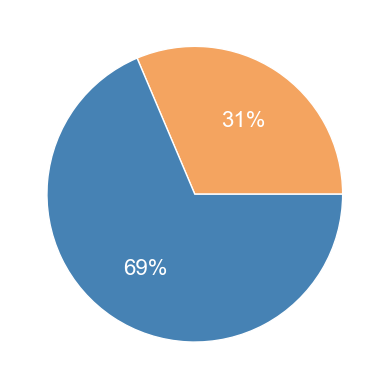

In [43]:
_,_,pcts = plt.pie([102, 223], #325-223
        colors=['sandybrown','steelblue'],
        autopct='%.0f%%',textprops={'size':16});

# Colors percents white
for pct in pcts:
    pct.set_color('white')

plt.savefig(f'./output_qc/qc_passed_failed_after_p4_ctherm_piechart.png', transparent=False, dpi=300)

plt.show()

In [43]:
# checking
len(df_metadata_final.project.unique())

11

### FIN